# Timeline
- Hash Functions
- Merkle Tree
- Cryptography: DSA, RSA, ECDSA
- HW1

# Hash Functions

A hash function is a function $h : A \to B$ where  

$$
A = \{ a \in \{0,1\}^j : j \in \mathbb{N} \}
\quad \text{arbitrary length bit sequences}
$$

$$
B = \{0,1\}^k \quad \text{for a fixed } k \in \mathbb{N} \text{ (fixed length bit sequences)}
$$


In [10]:
import random

SEED = 42
RANDOM = random.Random(SEED)

def random_ascii_string(length: int, rng: random.Random = RANDOM) -> str:
    alphabet = [chr(c) for c in range(32, 127)]
    return ''.join(rng.choice(alphabet) for _ in range(length))

In [11]:
message = "Hello, students"
hash(message)

5912768090043404716

In [12]:
json_message = '{"name": "John", "age": 30}'
hash(json_message)

2376509549821695384

In [25]:
random_message = random_ascii_string(128)
random_message

'd/ZOvvAjPqO-v=\\#ogIn<r(q[yFsT.1%$F_.,>d1QZOuyeUk}3Us,^nTC$xO;XX>N,wOerM\'RC8/Z+t;rql"&J?0h:(f:k;=J2l C20e@6.t#0!M>kI"6A&0~Uc.(\\YN'

In [38]:
def calculate_simple_hash(s: str, bits: int = 256, as_hex: bool = True):
    mask = (1 << bits) - 1
    h = sum(s.encode("utf-8")) & mask
    return h if not as_hex else f"{h:0{bits//4}x}"

In [40]:
%%time
calculate_simple_hash(random_message)

CPU times: total: 0 ns
Wall time: 10.7 μs


'000000000000000000000000000000000000000000000000000000000000264c'

In [7]:
calculate_simple_hash('abc')

'0000000000000000000000000000000000000000000000000000000000000126'

In [8]:
calculate_simple_hash('abc1')

'0000000000000000000000000000000000000000000000000000000000000157'

In [9]:
%%time
calculate_simple_hash(random_message * 1_000_000)

CPU times: user 533 ms, sys: 1.5 s, total: 2.04 s
Wall time: 1.99 s


'0000000000000000000000000000000000000000000000000000000258197d00'

In [10]:
calculate_simple_hash(random_message) == calculate_simple_hash(random_message)

True

In [11]:
calculate_simple_hash(random_message*1000), calculate_simple_hash(random_message*1000 + '123')

('000000000000000000000000000000000000000000000000000000000099a020',
 '000000000000000000000000000000000000000000000000000000000099a0b6')

In [12]:
calculate_simple_hash(random_message.upper()), calculate_simple_hash(message)

('00000000000000000000000000000000000000000000000000000000000022f4',
 '00000000000000000000000000000000000000000000000000000000000005ba')

### Why this hash function is bad?

## Cryptographic Hash Functions

For the properties below *infeasible* means hard to compute in any reasonable time with the existing computing power.  

- **One-way function (Preimage resistance):**  
  $$
  \forall b \in B \;\; \text{it is infeasible to find } a \in A : h(a) = b
  $$

- **Weak collision resistance (Second preimage resistance):**  
  $$
  \forall a \in A \;\; \text{it is infeasible to find } a' \in A : a' \neq a \text{ and } h(a) = h(a')
  $$

- **Strong collision resistance (Collision resistance):**  
  $$
  \text{It is infeasible to find any pair } a, a' \in A : a \neq a' \text{ and } h(a) = h(a')
  $$

In [13]:
import hashlib

def calculate_md5(data):
    return hashlib.md5(data.encode('utf-8')).hexdigest()

calculate_md5(message)

'38ecef94595ee7c494e01e5fec701809'

In [14]:
# open terminal and run
# md5 main.py      (macOS)
# md5sum main.py   (Linux)

https://www.mscs.dal.ca/~selinger/md5collision/

In [15]:
import hashlib

msg1 = bytes.fromhex(
    "d131dd02c5e6eec4693d9a0698aff95c2fcab58712467eab4004583eb8fb7f89"
    "55ad340609f4b30283e488832571415a085125e8f7cdc99fd91dbdf280373c5b"
    "d8823e3156348f5bae6dacd436c919c6dd53e2b487da03fd02396306d248cda0"
    "e99f33420f577ee8ce54b67080a80d1ec69821bcb6a8839396f9652b6ff72a70"
)

msg2 = bytes.fromhex(
    "d131dd02c5e6eec4693d9a0698aff95c2fcab50712467eab4004583eb8fb7f89"
    "55ad340609f4b30283e4888325f1415a085125e8f7cdc99fd91dbd7280373c5b"
    "d8823e3156348f5bae6dacd436c919c6dd53e23487da03fd02396306d248cda0"
    "e99f33420f577ee8ce54b67080280d1ec69821bcb6a8839396f965ab6ff72a70"
)

hash1 = hashlib.md5(msg1).hexdigest()
hash2 = hashlib.md5(msg2).hexdigest()

print(f"MD5 hash 1: {hash1}")
print(f"MD5 hash 2: {hash2}")

if hash1 == hash2:
    print("Collision detected")

MD5 hash 1: 79054025255fb1a26e4bc422aef54eb4
MD5 hash 2: 79054025255fb1a26e4bc422aef54eb4
Collision detected


In [16]:
def calculate_sha1(data):
    return hashlib.sha1(data.encode('utf-8')).hexdigest()

calculate_sha1(message)

'4a4c3f88d4a616b7e06743e1295a5a898c93adde'

In [17]:
def calculate_sha256(data):
    return hashlib.sha256(data.encode('utf-8')).hexdigest()

calculate_sha256(message)

'2002239a8a288a06fab87a1cc2bc6fc9908d1dbb45d5a000dbf7ba63bdadbaf2'

In [18]:
!python -m pip install "eth-hash[pycryptodome]"

Defaulting to user installation because normal site-packages is not writeable


In [19]:
from eth_hash.auto import keccak

def calculate_keccak256(data):
    keccak_hash = keccak(data.encode('utf-8'))
    return keccak_hash.hex()

calculate_keccak256(message)

'70a12069559c87610c14ed4e9c883a39b4bada91f74234150ecb0bf425a87235'

## SHA256

In [42]:
x = '123'
x.encode('utf-8')

b'123'

the Merkle–Damgård construction

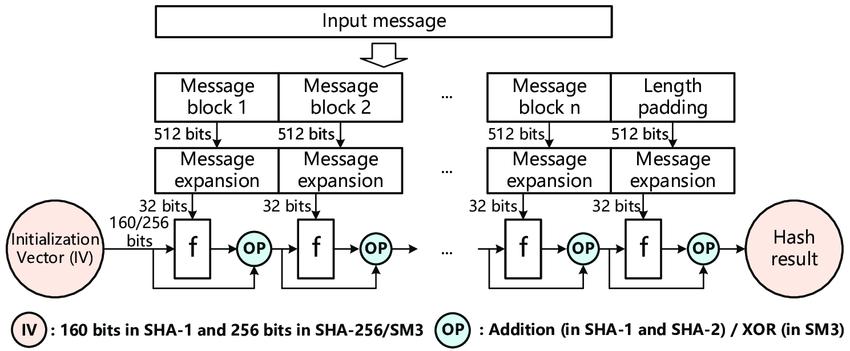

In [20]:
import struct
import hashlib  # used only for cross-check at the end

# K constants used in each SHA-256 round.
# They are the first 32 bits of the fractional parts of the cube roots of the first 64 prime numbers.
K = [
    0x428a2f98, 0x71374491, 0xb5c0fbcf, 0xe9b5dba5,
    0x3956c25b, 0x59f111f1, 0x923f82a4, 0xab1c5ed5,
    0xd807aa98, 0x12835b01, 0x243185be, 0x550c7dc3,
    0x72be5d74, 0x80deb1fe, 0x9bdc06a7, 0xc19bf174,
    0xe49b69c1, 0xefbe4786, 0x0fc19dc6, 0x240ca1cc,
    0x2de92c6f, 0x4a7484aa, 0x5cb0a9dc, 0x76f988da,
    0x983e5152, 0xa831c66d, 0xb00327c8, 0xbf597fc7,
    0xc6e00bf3, 0xd5a79147, 0x06ca6351, 0x14292967,
    0x27b70a85, 0x2e1b2138, 0x4d2c6dfc, 0x53380d13,
    0x650a7354, 0x766a0abb, 0x81c2c92e, 0x92722c85,
    0xa2bfe8a1, 0xa81a664b, 0xc24b8b70, 0xc76c51a3,
    0xd192e819, 0xd6990624, 0xf40e3585, 0x106aa070,
    0x19a4c116, 0x1e376c08, 0x2748774c, 0x34b0bcb5,
    0x391c0cb3, 0x4ed8aa4a, 0x5b9cca4f, 0x682e6ff3,
    0x748f82ee, 0x78a5636f, 0x84c87814, 0x8cc70208,
    0x90befffa, 0xa4506ceb, 0xbef9a3f7, 0xc67178f2
]

# Initial hash values H.
# They are the first 32 bits of the fractional parts of the square roots of the first 8 prime numbers.
H = [
    0x6a09e667,  # H0
    0xbb67ae85,  # H1
    0x3c6ef372,  # H2
    0xa54ff53a,  # H3
    0x510e527f,  # H4
    0x9b05688c,  # H5
    0x1f83d9ab,  # H6
    0x5be0cd19   # H7
]

def right_rotate(value: int, shift: int) -> int:
    """
    Right rotate (circular right shift) a 32-bit integer by 'shift' bits.
    """
    # '& 0xFFFFFFFF' keeps the result within 32 bits.
    return ((value >> shift) | (value << (32 - shift))) & 0xFFFFFFFF

# f
def sha256_compress(chunk: bytes, h_values: list[int]) -> list[int]:
    """
    SHA-256 compression function that processes one 512-bit block ('chunk').
    """
    # Split the 512-bit block into 16 big-endian 32-bit words and extend to 64 words.
    w = list(struct.unpack('>16L', chunk)) + [0] * 48
    # '>16L' means 16 unsigned 32-bit integers in big-endian order.

    # Message schedule: extend 16 words to 64 using σ0 and σ1.
    for i in range(16, 64):
        s0 = right_rotate(w[i - 15], 7) ^ right_rotate(w[i - 15], 18) ^ (w[i - 15] >> 3)
        s1 = right_rotate(w[i - 2], 17) ^ right_rotate(w[i - 2], 19) ^ (w[i - 2] >> 10)
        w[i] = (w[i - 16] + s0 + w[i - 7] + s1) & 0xFFFFFFFF  # ensure 32-bit result

    # Initialize working variables with the current hash state.
    a, b, c, d, e, f, g, h = h_values

    # Main loop: 64 rounds.
    # diffusion
    for i in range(64):
        # Compute the round functions and temporaries.
        S1 = right_rotate(e, 6) ^ right_rotate(e, 11) ^ right_rotate(e, 25)
        ch = (e & f) ^ (~e & g)         # choice function
        temp1 = (h + S1 + ch + K[i] + w[i]) & 0xFFFFFFFF

        S0 = right_rotate(a, 2) ^ right_rotate(a, 13) ^ right_rotate(a, 22)
        maj = (a & b) ^ (a & c) ^ (b & c)  # majority function
        temp2 = (S0 + maj) & 0xFFFFFFFF

        # Update working variables.
        h = g
        g = f
        f = e
        e = (d + temp1) & 0xFFFFFFFF
        d = c
        c = b
        b = a
        a = (temp1 + temp2) & 0xFFFFFFFF

    # Compute the new intermediate hash state by adding the working vars.
    return [
        (h_values[0] + a) & 0xFFFFFFFF,
        (h_values[1] + b) & 0xFFFFFFFF,
        (h_values[2] + c) & 0xFFFFFFFF,
        (h_values[3] + d) & 0xFFFFFFFF,
        (h_values[4] + e) & 0xFFFFFFFF,
        (h_values[5] + f) & 0xFFFFFFFF,
        (h_values[6] + g) & 0xFFFFFFFF,
        (h_values[7] + h) & 0xFFFFFFFF,
    ]

def sha256(data: str) -> str:
    """
    Compute SHA-256 digest of a UTF-8 string and return a hex string.
    """
    # Convert input string to UTF-8 bytes.
    data_bytes = bytearray(data.encode('utf-8'))
    original_len_bits = len(data_bytes) * 8  # message length in bits

    # Append the '1' bit (as 0x80) followed by k '0' bits.
    data_bytes.append(0x80)

    # Pad with zeros until length ≡ 448 (mod 512) so that we can append a 64-bit length.
    while (len(data_bytes) * 8 + 64) % 512 != 0:
        data_bytes.append(0)

    # Append original length as 64-bit big-endian integer.
    data_bytes += struct.pack('>Q', original_len_bits)

    # Initialize hash state.
    h_values = H[:]

    # Process the message in successive 512-bit (64-byte) chunks.
    for i in range(0, len(data_bytes), 64):
        chunk = data_bytes[i:i + 64]
        h_values = sha256_compress(chunk, h_values)

    # Produce the final 256-bit digest as hex.
    return ''.join(f'{x:08x}' for x in h_values)


msg = "Hello, SHA-256!"
print(f' Custom SHA-256("{msg}") = {sha256(msg)}')
print(f'Library SHA-256("{msg}") = {calculate_sha256(msg)}')


 Custom SHA-256("Hello, SHA-256!") = d0e8b8f11c98f369016eb2ed3c541e1f01382f9d5b3104c9ffd06b6175a46271
Library SHA-256("Hello, SHA-256!") = d0e8b8f11c98f369016eb2ed3c541e1f01382f9d5b3104c9ffd06b6175a46271


## Avalanche effect

In [21]:
def hex_to_int(h: str) -> int:
    return int(h, 16)

def flip_one_bit_in_text(s: str, rng: random.Random = RANDOM) -> str:
    """Flip a single bit in the UTF-8 bytes of s; if decoding fails, flip a char's LSB instead."""
    b = bytearray(s.encode('utf-8'))
    idx = rng.randrange(len(b))
    bit = 1 << rng.randrange(8)
    b[idx] ^= bit
    try:
        return b.decode('utf-8')
    except UnicodeDecodeError:
        pos = rng.randrange(len(s))
        return s[:pos] + chr(ord(s[pos]) ^ 1) + s[pos+1:]

In [22]:
random_message

"q.#~C?<1~-v~e+kV$#+;=`m#g9{syeU<YkC 4yVKC3;K-+P,MLmA%}Zd/P*fEpoNi8z(%t=E*=,PCZqN4OM:uBywr)mq5d}?4[PBqxg<wI'=$HSB(;h{H;s_RrZ2A1?g"

In [23]:
calculate_sha256(random_message)

'bc405ec3cd5c069065e1dedb18038e6260fad2412632d0897a9c1846ceea1023'

In [24]:
flipped_message = flip_one_bit_in_text(random_message)
flipped_message

"q.#~C?<1~-v~e+kV$#+;=`m#g9{syeU<YkC 4yVKC3;K-+P,MLmA%}Zd/P*fEpoNi8zh%t=E*=,PCZqN4OM:uBywr)mq5d}?4[PBqxg<wI'=$HSB(;h{H;s_RrZ2A1?g"

In [25]:
print(flipped_message != random_message)

True


In [26]:
calculate_sha256(flipped_message)

'3b9963f112fdd571f2009d837e7d510a2f8dd351281546dd516fab582240e44b'

## Hamming Distance


The Hamming distance is the number of positions where two bitstrings differ.

Given two bitstrings $(x, y \in \{0,1\}^n)$, the Hamming distance is:

$$
d_H(x,y) = \sum_{i=1}^{n} [x_i \neq y_i]
$$


In [27]:
def hamming_distance(a: int, b: int) -> int:
    return (a ^ b).bit_count()

def hamming_distance_hex(h1: str, h2: str) -> int:
    """Hamming distance between two equal-width hex strings."""
    return hamming_distance(int(h1, 16), int(h2, 16))

In [28]:
original_hash = calculate_sha256(random_message)
flipped_hash = calculate_sha256(flipped_message)

In [29]:
hamming_distance_hex(original_hash, flipped_hash) / 256

0.5234375

## Benchmarks

In [30]:
!pip3 install tqdm

Defaulting to user installation because normal site-packages is not writeable


In [31]:
import hashlib
import random
import time

import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from typing import Callable, Dict, Iterable


HASHES_HEX: Dict[str, Callable[[str], str]] = {
    "sum_hash": calculate_simple_hash,
    "md5": calculate_md5,
    "sha1": calculate_sha1,
    "sha256": calculate_sha256,
    "keccak256": calculate_keccak256,
}

def hash_hex(name: str, s: str) -> str:
    return HASHES_HEX[name](s)

### Benchmark 1: Speed / Throughput

To compare how fast different hash functions process data.

**What it shows**  
- Computation time per byte.  
- Throughput in MB/s.  
- Trade-offs between lightweight (MD5/SHA-1) and secure (SHA-256/Keccak-256).  

**Formulas**  


$$
\text{MB/s} = \frac{N_{\text{bytes}}}{T \cdot 1024^2}
$$

where $T$ is wall-clock time and $N_{\text{bytes}}$ is total processed bytes.


In [32]:
# ---------- 1) Speed / Throughput ----------
def measure_time(func: Callable[[], None], repeats: int = 3) -> float:
    best = float('inf')
    for _ in range(repeats):
        t0 = time.perf_counter()
        func()
        best = min(best, time.perf_counter() - t0)
    return best

def benchmark_speed(
    names: Iterable[str] = ("sum_hash", "md5", "sha1", "sha256", "keccak256"),
    sizes: Iterable[int] = [i for i in range(1, 10_000, 100)],
    n_per_size: int = 100,
):
    rows = []
    # same inputs for every hash function -> fair comparison, generated once
    samples = {L: [random_ascii_string(L) for _ in range(n_per_size)] for L in sizes}
    for name in tqdm(names):
        for L in sizes:
            strings = samples[L]
            def run():
                acc = 0
                for s in strings:
                    acc ^= hex_to_int(hash_hex(name, s))
                return acc
            elapsed = measure_time(run, repeats=3)
            total_bytes = n_per_size * L
            ns_per_byte = (elapsed / total_bytes) * 1e9
            mbps = (total_bytes / elapsed) / (1024 * 1024)
            rows.append((name, L, ns_per_byte, mbps, elapsed))
    return pd.DataFrame(rows, columns=["hash","size_bytes","ns_per_byte","MB_per_s", "elapsed"])

def plot_speed(df: pd.DataFrame):
    # MB/s vs size
    plt.figure()
    for name, sub in df.groupby("hash"):
        sub = sub.sort_values("size_bytes")
        plt.plot(sub["size_bytes"], sub["MB_per_s"], marker="o", label=name)
    plt.xlabel("Input size (bytes)")
    plt.ylabel("MB/s")
    plt.title("Speed: throughput vs input size")
    plt.legend()
    plt.grid(True)

    # elapsed vs size
    plt.figure()
    for name, sub in df.groupby("hash"):
        sub = sub.sort_values("size_bytes")
        plt.plot(sub["size_bytes"], sub["elapsed"], marker="o", label=name)
    plt.xlabel("Input size (bytes)")
    plt.ylabel("elapsed (s)")
    plt.title("Speed: elapsed time vs input size")
    plt.legend()
    plt.grid(True)

100%|██████████| 5/5 [00:01<00:00,  2.86it/s]


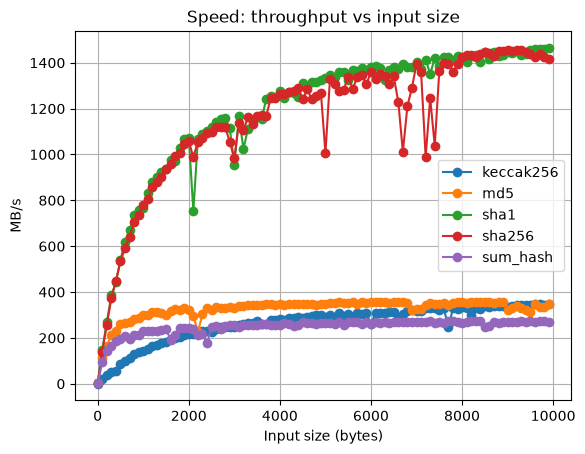

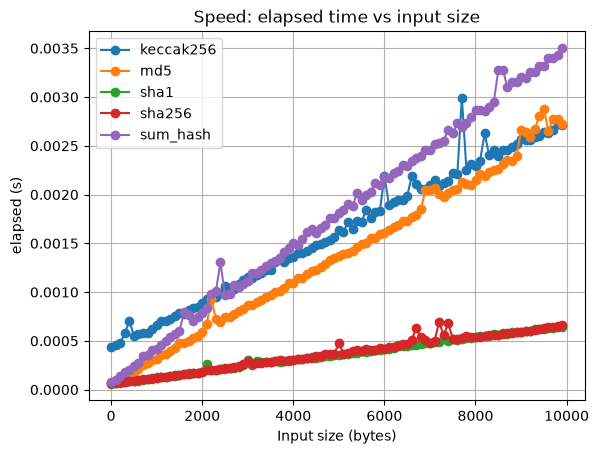

In [33]:
df_speed = benchmark_speed()
plot_speed(df_speed)

### Benchmark 2: Avalanche Effect

To measure **diffusion**: how much the output changes when flipping one input bit.

**What it shows**  
- How uniformly changes propagate across output bits.  
- Cryptographic hashes should flip about half the bits on average.  

In [61]:
# ---------- 2) Avalanche Effect ----------

def _digest_bits_native(name: str) -> int:
    """Infer native bit-width from hex digest length."""
    hx = hash_hex(name, "")
    return len(hx) * 4

def test_avalanche(
    names: Iterable[str] = ("sum_hash", "md5", "sha1", "sha256", "keccak256"),
    input_len: int = 256,
    samples: int = 10_000,
) -> pd.DataFrame:
    """
    Measure Avalanche Effect for each hash using its *native* output width.
    Returns a DataFrame with: hash, bits, avg_flipped_bits, ideal, ratio.
    """
    rng = RANDOM
    rows = []
    for name in names:
        bits = _digest_bits_native(name)
        total = 0
        for _ in range(samples):
            s = random_ascii_string(input_len)
            s_flipped = flip_one_bit_in_text(s)

            # Compute Hamming distance between native-width outputs
            h1 = int(hash_hex(name, s), 16)
            h2 = int(hash_hex(name, s_flipped), 16)
            total += hamming_distance(h1, h2)

        avg = total / samples
        ideal = bits / 2.0
        share = avg / bits
        ratio = avg / ideal if ideal else float('nan')
        rows.append((name, bits, avg, ideal, ratio, share))

    return pd.DataFrame(rows, columns=["hash", "bits", "avg_flipped_bits", "ideal", "ratio", "share"])

def plot_avalanche(df: pd.DataFrame):
    """
    Bar chart of average flipped bits per hash with per-hash ideal markers (bits/2).
    """
    plt.figure()
    dfp = df.sort_values("avg_flipped_bits")
    x_labels = list(dfp["hash"])
    y_vals = list(dfp["share"])
    ideals = [0.5] * len(y_vals)

    # Bars: observed averages
    plt.bar(x_labels, y_vals)
    # Overlay per-hash ideal markers
    plt.plot(x_labels, ideals, marker="o", linestyle="none")

    plt.ylabel("share (avg flipped / bits)")
    plt.title("Avalanche Effect")
    plt.grid(True, axis='y')

In [62]:
df_avalanche = test_avalanche()

In [63]:
df_avalanche

,hash,bits,avg_flipped_bits,ideal,ratio,share
0,sum_hash,256,2.0235,128.0,0.015809,0.007904
1,md5,128,64.0367,64.0,1.000573,0.500287
2,sha1,160,79.9739,80.0,0.999674,0.499837
3,sha256,256,127.9701,128.0,0.999766,0.499883
4,keccak256,256,128.0128,128.0,1.000100,0.500050


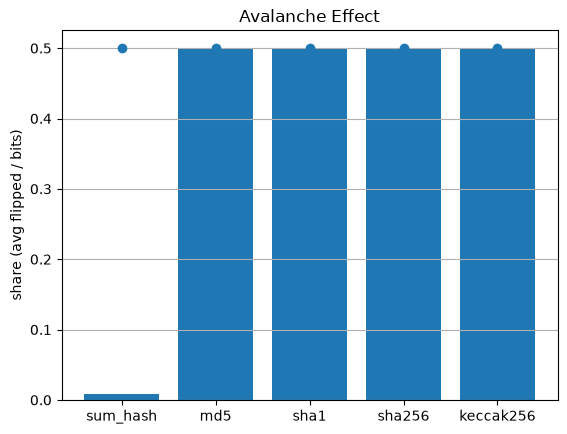

In [64]:
plot_avalanche(df_avalanche)

### Benchmark 3: Uniformity (χ² Test)
To check whether outputs spread evenly across buckets (low bits distribution).

**What it shows**  
- Closeness to uniform distribution.  
- High χ² means bias.  

**Formulas**  

With $N$ samples, $B = 2^k$ buckets, expected count per bucket $E = \frac{N}{B}$:  

$$
\chi^2 = \sum_{i=1}^{B} \frac{(O_i - E)^2}{E}
$$

where O_i is observed count in bucket i.

In [65]:
# ---------- 3) Uniformity (χ² over buckets) ----------
import math


def truncate_int(x: int, bits: int) -> int:
    return x & ((1 << bits) - 1) if bits < 256 else x

def hash_as_int_trunc(name: str, s: str, out_bits: int) -> int:
    return truncate_int(hex_to_int(hash_hex(name, s)), out_bits)

def chi_square_uniformity(
    names: Iterable[str] = ("sum_hash", "md5", "sha1", "sha256", "keccak256"),
    out_bits: int = 64,
    bucket_bits: int = 11,
    N: int = 1_000_000,
):
    rng = RANDOM
    B = 1 << bucket_bits
    expected = N / B
    rows = []
    samples = [random_ascii_string(32) for _ in range(N)]  # generated once
    for name in names:
        counts = [0] * B
        for s in samples:
            h = hash_as_int_trunc(name, s, out_bits)
            counts[h & (B - 1)] += 1
        chi2 = sum(((c - expected) ** 2) / expected for c in counts)
        max_dev = max(abs(c - expected) for c in counts)
        rows.append((name, B, N, chi2, max_dev))
    return pd.DataFrame(rows, columns=["hash","buckets","samples","chi2","max_abs_dev"])

def plot_uniformity(df: pd.DataFrame, title_suffix: str = "low bits"):
    """
    Reading guide:
      - Bars near 1 and inside the shaded band look good.
      - Large |z| (≈ > 2) may indicate bias; consider more samples or test high bits.
    """
    if df.empty:
        raise ValueError("Empty dataframe passed to plot_uniformity")

    # Shared parameters (assumed identical across rows)
    B = int(df["buckets"].iloc[0])
    N = int(df["samples"].iloc[0])
    dof = B - 1

    # Normalize chi² and compute z-scores under H0 (uniform):
    # E[chi²] = dof, Var[chi²] = 2*dof  => sd = sqrt(2*dof)
    chi2_mean = dof
    chi2_sd = math.sqrt(2.0 * dof)

    dfp = df.copy()
    dfp["chi2_per_df"] = dfp["chi2"] / dof
    dfp["z_score"] = (dfp["chi2"] - chi2_mean) / chi2_sd

    # For chi²/dof the sd is sqrt(2/dof)
    sd_norm = math.sqrt(2.0 / dof)
    band_lo, band_hi = 1 - 2 * sd_norm, 1 + 2 * sd_norm  # ±2σ band

    # --- Single figure ---
    plt.figure()
    df_sorted = dfp.sort_values("chi2_per_df")
    x = list(df_sorted["hash"])
    y = list(df_sorted["chi2_per_df"])
    z = list(df_sorted["z_score"])

    # Bars: chi²/dof
    plt.bar(x, y)

    # Ideal line and ±2σ band
    plt.axhline(1.0, linestyle="--")
    plt.fill_between([-0.5, len(x) - 0.5], band_lo, band_hi, alpha=0.15)

    # Annotate z-scores above bars
    for xi, yi, zi in zip(range(len(x)), y, z):
        plt.text(xi, yi, f"z={zi:.2f}", ha="center", va="bottom")

    plt.ylabel("chi² / dof  (ideal ≈ 1)")
    plt.title(f"Uniformity (χ² normalized) — {title_suffix}")
    plt.grid(True, axis="y")

In [66]:
df_uniform = chi_square_uniformity()

In [67]:
df_uniform

,hash,buckets,samples,chi2,max_abs_dev
0,sum_hash,2048,1000000,2.722760e+06,2171.71875
1,md5,2048,1000000,2.001658e+03,87.28125
2,sha1,2048,1000000,2.067358e+03,83.28125
3,sha256,2048,1000000,2.051125e+03,74.71875
4,keccak256,2048,1000000,1.963299e+03,66.71875


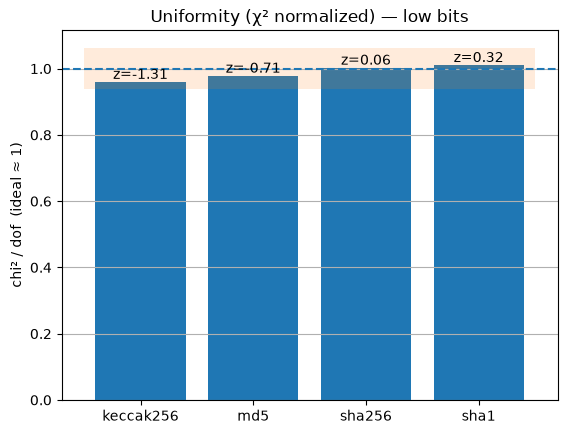

In [68]:
plot_uniformity(df_uniform[df_uniform.hash != 'sum_hash'])

### Benchmark 4: Collisions (Birthday Test)

To estimate collision frequency under truncation (e.g., 32-bit).  

$$
\mathbb{E}[\text{collisions}] \approx \frac{N (N-1)}{2 \cdot 2^b}
$$

where $N$ = number of hashes, $b$ = number of bits after truncation.

In [69]:
# ---------- 4) Collisions under truncation ----------
def collision_test(
    names: Iterable[str] = ("sum_hash", "md5", "sha1", "sha256", "keccak256"),
    out_bits: int = 32,
    N: int = 500_000,
):
    rng = RANDOM
    rows = []
    samples = [random_ascii_string(32) for _ in range(N)]  # generated once
    for name in names:
        seen = set()
        collisions = 0
        for s in samples:
            h = hash_as_int_trunc(name, s, out_bits)
            if h in seen: collisions += 1
            else: seen.add(h)
        expected = (N * (N - 1)) / (2 * (1 << out_bits))
        rows.append((name, out_bits, N, collisions, expected))
    return pd.DataFrame(rows, columns=["hash","bits","N","collisions","expected_birthday"])

def plot_collisions(df: pd.DataFrame):
    plt.figure()
    df_sorted = df.sort_values("collisions")
    plt.bar(df_sorted["hash"], df_sorted["collisions"])
    expected = df_sorted["expected_birthday"].iloc[0]
    plt.axhline(expected, linestyle="--")
    plt.ylabel("Observed collisions")
    plt.title("Collisions under truncation")
    plt.text(0.5, expected, f'Expected ≈ {expected:.1f}', va='bottom')
    plt.grid(True, axis='y')

In [70]:
df_coll = collision_test()

In [71]:
df_coll

,hash,bits,N,collisions,expected_birthday
0,sum_hash,32,500000,498790,29.103772
1,md5,32,500000,28,29.103772
2,sha1,32,500000,20,29.103772
3,sha256,32,500000,22,29.103772
4,keccak256,32,500000,32,29.103772


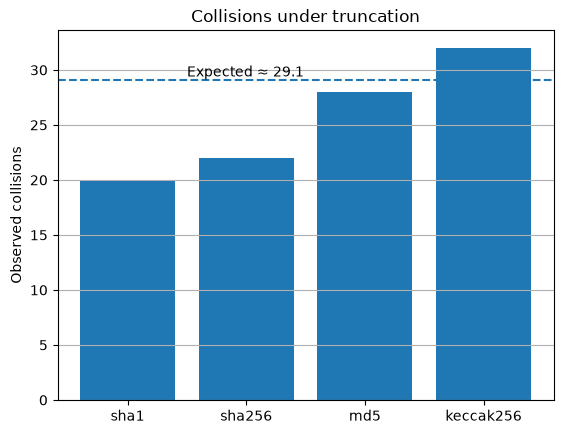

In [72]:
plot_collisions(df_coll[df_coll.hash != 'sum_hash'])

### Benchmark 5: Bit Balance
To verify that each output bit is 1 about 50% of the time.  

**What it shows**  
- Per-bit ones frequency.  
- Average and worst deviation from 0.5.  

**Formulas**  

For bit position \(j\):  

$$
p_j = \frac{1}{N} \sum_{i=1}^{N} \text{bit}_j(h(x_i))
$$

Average deviation:  

$$
\text{AvgDev} = \frac{1}{b} \sum_{j=1}^{b} \big|p_j - 0.5\big|
$$

Worst deviation:  

$$
\text{WorstDev} = \max_{j} \big|p_j - 0.5\big|
$$

where \(b\) is the number of output bits considered (e.g., 64 after truncation).

In [73]:
# ---------- 5) Bit balance ----------
def bit_balance(
    names: Iterable[str] = ("sum_hash", "md5", "sha1", "sha256", "keccak256"),
    out_bits: int = 64,
    N: int = 500_000,
):
    rng = RANDOM
    rows = []
    samples = [random_ascii_string(48, rng) for _ in range(N)]  # generated once
    for name in names:
        ones = [0] * out_bits
        for s in samples:
            h = hash_as_int_trunc(name, s, out_bits)
            for b in range(out_bits):
                ones[b] += (h >> b) & 1
        freqs = [x / N for x in ones]
        avg_dev = sum(abs(f - 0.5) for f in freqs) / out_bits
        worst_dev = max(abs(f - 0.5) for f in freqs)
        rows.append((name, out_bits, N, avg_dev, worst_dev))
    return pd.DataFrame(rows, columns=["hash","bits","N","avg_abs_dev","worst_abs_dev"])

def plot_bit_balance(df: pd.DataFrame):
    plt.figure()
    df_sorted = df.sort_values("avg_abs_dev")
    plt.bar(df_sorted["hash"], df_sorted["avg_abs_dev"])
    plt.ylabel("Avg |p(bit=1) - 0.5| (lower is better)")
    plt.title("Bit balance")
    plt.grid(True, axis='y')

In [74]:
df_balance = bit_balance()

In [75]:
df_balance

,hash,bits,N,avg_abs_dev,worst_abs_dev
0,sum_hash,64,500000,0.424553,0.500000
1,md5,64,500000,0.000625,0.001792
2,sha1,64,500000,0.000528,0.001648
3,sha256,64,500000,0.000590,0.001802
4,keccak256,64,500000,0.000661,0.001748


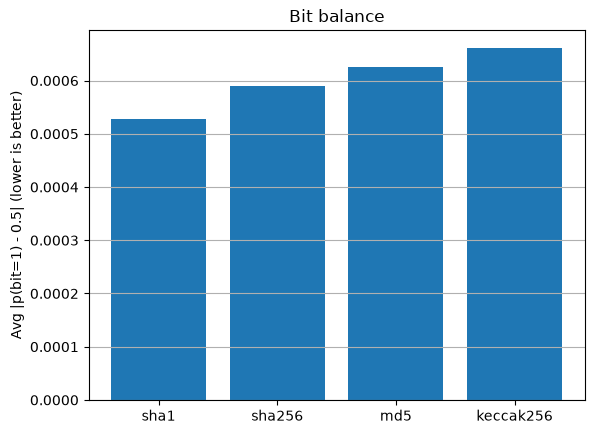

In [76]:
plot_bit_balance(df_balance[df_balance.hash != 'sum_hash'])

# Merkle Tree

In [77]:
import json


class Transaction:
    def __init__(self, tx_id: int, amount: float, message: str):
        self._tx_id: int = tx_id
        self._amount: float = amount
        self._message: str = message

    def json(self) -> str:
        data: dict = {
            'tx_id': self._tx_id,
            'amount': self._amount,
            'message': self._message
        }
        return json.dumps(data)

    def __repr__(self) -> str:
        return self.json()

In [78]:
tx = Transaction(tx_id=0, amount=10, message='test1')
tx.json()

'{"tx_id": 0, "amount": 10, "message": "test1"}'

In [79]:
calculate_sha256(tx.json())

'eaf21183ccc49053c15177a11189db0917832605d642b617e60ed1be8b02835b'

**Merkle tree is a binary tree built with a hash function $H$**

Let $d_1, \dots, d_n$ be the input data.

- Leaves (level 0):
$$
L_{0,i} = H(d_i), \quad i = 1, \dots, n
$$

- Internal nodes (level $\ell \ge 1$):
$$
L_{\ell,j} = H\big( L_{\ell-1,\,2j-1} \,\|\, L_{\ell-1,\,2j} \big)
$$
(if a level has an odd number of nodes, the last node is duplicated — Bitcoin convention)

- Root, where $k$ is the height of the tree:
$$
\text{MerkleRoot} = L_{k,1}
$$


In [80]:
from copy import deepcopy
from dataclasses import dataclass
from typing import List, Tuple, Optional


@dataclass
class MerkleNode:
    left: Optional["MerkleNode"]
    right: Optional["MerkleNode"]
    hash_value: str


class MerkleTree:

    def __init__(self, transactions: List[Transaction]):
        self._leaves: List[MerkleNode] = [MerkleNode(None, None, calculate_sha256(it.json())) for it in transactions]
        self._root: Optional[MerkleNode] = self._build()

    def _build(self) -> Optional[MerkleNode]:
        if not self._leaves:
            return None
        level: List[MerkleNode] = self._leaves
        while len(level) > 1:
            next_level: List[MerkleNode] = []
            # If odd, duplicate the last node
            if len(level) % 2 == 1:
                level = level + [level[-1]]
            for i in range(0, len(level), 2):
                left = level[i]
                right = level[i + 1]
                parent_hash = calculate_sha256(left.hash_value + right.hash_value)
                next_level.append(MerkleNode(left, right, parent_hash))
            level = next_level
        return level[0]

    @property
    def root(self) -> Optional[MerkleNode]:
        return self._root

    def merkle_root_hex(self) -> Optional[str]:
        return self._root.hash_value if self._root else None

In [81]:
tx1 = Transaction(1, 1.0, "Payment A")
tx2 = Transaction(2, 20.0, "Payment B")
tx3 = Transaction(3, 30.0, "Payment C")
tx4 = Transaction(4, 40.0, "Payment D")
tx5 = Transaction(5, 50.0, "Payment E")
tx6 = Transaction(6, 60.0, "Payment F")

transactions = [tx1, tx2, tx3, tx4, tx5, tx6]
transactions

[{"tx_id": 1, "amount": 1.0, "message": "Payment A"},
 {"tx_id": 2, "amount": 20.0, "message": "Payment B"},
 {"tx_id": 3, "amount": 30.0, "message": "Payment C"},
 {"tx_id": 4, "amount": 40.0, "message": "Payment D"},
 {"tx_id": 5, "amount": 50.0, "message": "Payment E"},
 {"tx_id": 6, "amount": 60.0, "message": "Payment F"}]

In [82]:
tree = MerkleTree(transactions)

In [83]:
tree._leaves

[MerkleNode(left=None, right=None, hash_value='564a47ac6b27a87cf51ad8b53ba2e090248edfbee21342080078038240be41bd'),
 MerkleNode(left=None, right=None, hash_value='ed2cf63e0bc15692de4363e3658faa5ff828fcb2a49a820baa6e10ad08f4cf26'),
 MerkleNode(left=None, right=None, hash_value='87ec5cd194485b401ced3e17e744b0e5012be7dc26049e636840546e326b599f'),
 MerkleNode(left=None, right=None, hash_value='98d142350b732e232563d3f172761687bcd9891bbd51556d69fd76f161dad224'),
 MerkleNode(left=None, right=None, hash_value='15b0d0e0229dbd7ec85c7f43a2bde59d53f49380f584ab33bd73e5dba5c7fbf5'),
 MerkleNode(left=None, right=None, hash_value='027df4db42c2bd033df752e6dbe480bba33822393c6ab3ebbf39d0643daa701c')]

In [84]:
tree.merkle_root_hex()

'99ad78390b32c76060ff5e38a78e568586a09ecffd0659c359f3aaea3c5ce39b'

In [85]:
calculate_sha256(
    tree.root.left.hash_value +\
    tree.root.right.hash_value
)

'99ad78390b32c76060ff5e38a78e568586a09ecffd0659c359f3aaea3c5ce39b'

In [86]:
tree.root.right.right.hash_value, tree.root.right.left.hash_value

('3675f0474ed5e8cc4e5052d4920af5f3cbff151c889a3ec6d40b518206b210ba',
 '3675f0474ed5e8cc4e5052d4920af5f3cbff151c889a3ec6d40b518206b210ba')

In [87]:
!pip3 install graphviz

Defaulting to user installation because normal site-packages is not writeable


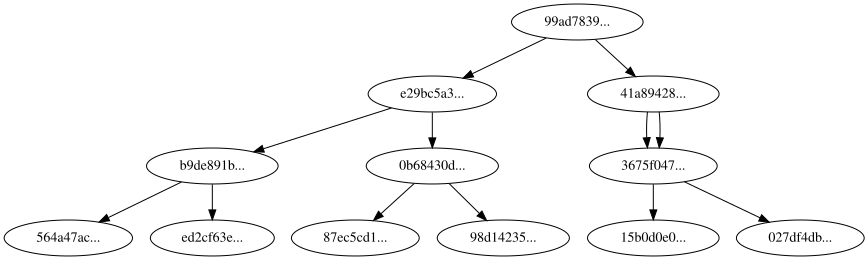

In [88]:
import graphviz

def visualize_merkle_tree(tree):
    dot = graphviz.Digraph(comment='Merkle Tree')
    visited = {}

    def add_node(node):
        if node.hash_value in visited:
            return
        visited[node.hash_value] = node.hash_value[:8] + '...'
        dot.node(node.hash_value, label=visited[node.hash_value])
        if node.left:
            dot.edge(node.hash_value, node.left.hash_value)
            add_node(node.left)
        if node.right:
            dot.edge(node.hash_value, node.right.hash_value)
            add_node(node.right)

    add_node(tree.root)
    return dot

visualize_merkle_tree(tree)

**Merkle proof**

- Proof for element $d_k$:
$$
P(d_k) = \{ h_1, h_2, \dots, h_m \}
$$

- Verification:
$$
\hat{R} = \text{combine}\big(H(d_k), P(d_k)\big), \quad \hat{R} \stackrel{?}{=} R
$$

https://medium.com/crypto-0-nite/merkle-proofs-explained-6dd429623dc5

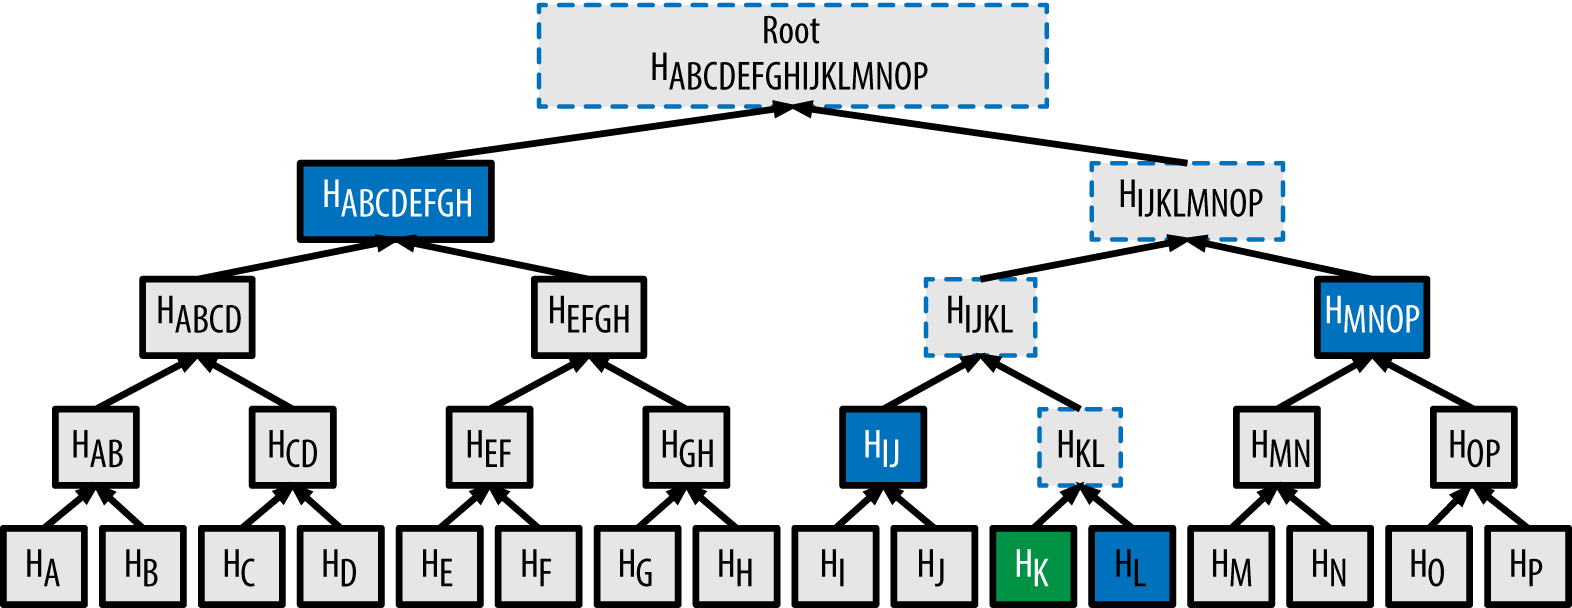

 # Cryptography

We have

$$
E(k_{e}, m) = c, \quad D(k_{d}, c) = m
$$

Where $E$ and $D$ - encryption and decryption algo, $k_{e}$ and $k_{d}$ - encryption and decryption key, $m$ - initial message, $c$ - ciphertext

### Symmetric Key

$$
k_{e} = k_{d} = k => E(k, m) = c, \quad D(k, c) = m
$$

### Asymmetric cryptography

$$
E(e, m) = c, \quad D(d, c) = m
$$

## RSA



**RSA Algorithm**

**Key generation**:
1. Choose two primes:
$$
p, q
$$

2. Compute modulus:
$$
n = p \cdot q
$$

3. Compute Euler's function:
$$
\varphi(n) = (p-1)(q-1)
$$

4. Choose $e$ such that:
$$
1 < e < \varphi(n), \quad \gcd(e, \varphi(n)) = 1
$$

5. Compute private exponent:
$$
d \equiv e^{-1} \pmod{\varphi(n)}
$$

- Public key: $(e, n)$  
- Private key: $(d, n)$  

**Encryption**:
$$
c = m^e \pmod{n}
$$

**Decryption**:
$$
m = c^d \pmod{n}
$$


## Elliptic Curve

**Elliptic curve (Weierstrass form)**

$$
E: y^2 = x^3 + ax + b, \quad a,b \in \mathbb{R}
$$

with the non-singularity condition:

$$
4a^3 + 27b^2 \neq 0
$$


https://www.desmos.com/calculator/ialhd71we3?lang=ru

**Point addition on the curve**

For two points $P=(x_1,y_1)$ and $Q=(x_2,y_2)$:

$$
\lambda =
\begin{cases}
\dfrac{y_2 - y_1}{x_2 - x_1}, & P \neq Q, \\
\dfrac{3x_1^2 + a}{2y_1}, & P = Q
\end{cases}
$$

$$
x_3 = \lambda^2 - x_1 - x_2
$$

$$
y_3 = \lambda(x_1 - x_3) - y_1
$$

Thus:
$$
P + Q = -R = (x_3, y_3)
$$


**Neutral element (point at infinity)**

$$
P + 0 = 0 + P = P
$$


**Inverse point**

$$
(x,y) + (x,-y) = 0
$$


### One Way function (ECDLP)

Scalar multiplication is easy:
$$
Q = nP \quad \text{(fast, } O(\log n) \text{ additions)}
$$

but recovering $n$ from $P$ and $Q$ (the elliptic curve discrete logarithm problem) is infeasible for well-chosen curves.


In [38]:
import numpy as np
import matplotlib.pyplot as plt

def modular_sqrt(a, p):
    for y in range(p):
        if (y * y) % p == a % p:
            return y
    return None

def plot_ec(a, b, p):
    x_vals = np.arange(p)
    points = []

    for x in x_vals:
        y2 = (int(x)**3 + a * int(x) + b) % p
        y = modular_sqrt(y2, p)
        if y is not None:
            points.append((x, y))
            if y != 0:                      # y and p - y are distinct only if y != 0
                points.append((x, p - y))

    plt.figure(figsize=(8, 9))
    x_coords, y_coords = zip(*points)
    plt.scatter(x_coords, y_coords, color="blue")
    plt.title(rf"Elliptic Curve: $y^2 = x^3 + {a}x + {b}$ (mod {p})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.axhline(0, color='black',linewidth=0.5)
    plt.axvline(0, color='black',linewidth=0.5)
    plt.show()


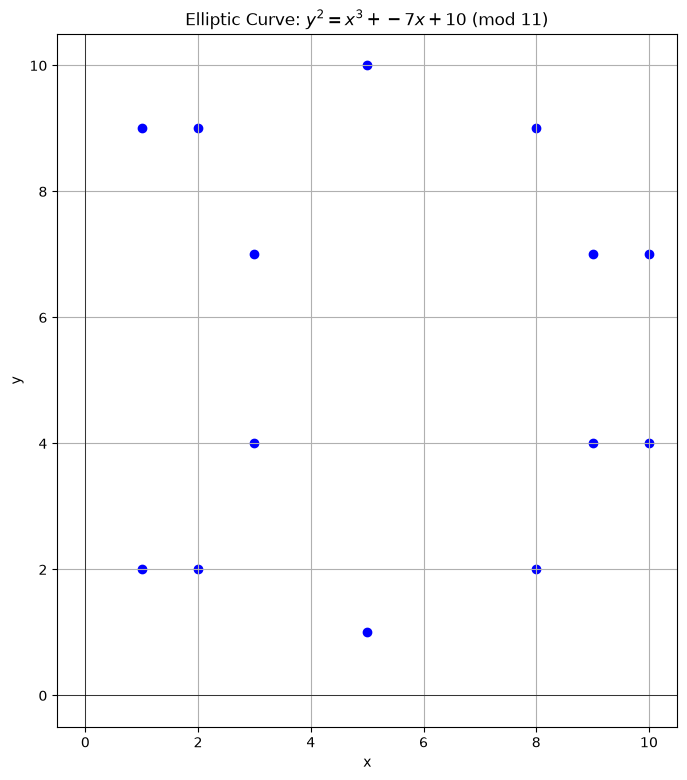

In [39]:
A = -7
B = 10
P = 11

plot_ec(A, B, P)

In [43]:
def inverse_mod(k, p):
    return pow(k, p - 2, p)  # Fermat: p must be prime

def is_on_curve(P, a, b, p):
    if P is None:
        return True
    x, y = P
    return (y * y - (x**3 + a * x + b)) % p == 0

def point_add(P, Q, a, p):
    if P is None:
        return Q
    if Q is None:
        return P
    x1, y1 = P
    x2, y2 = Q
    if x1 == x2 and y1 == -y2 % p:
        return None                      # P + (-P) = O
    if x1 == x2:
        m = (3 * x1**2 + a) * inverse_mod(2 * y1, p) % p
    else:
        m = (y2 - y1) * inverse_mod(x2 - x1, p) % p
    x3 = (m**2 - x1 - x2) % p
    y3 = (m * (x1 - x3) - y1) % p
    return (x3, y3)

# point mul scalar value (double-and-add)
def point_mul(k, P, a, p):
    result = None
    addend = P
    while k:
        if k & 1:
            result = point_add(result, addend, a, p)
        addend = point_add(addend, addend, a, p)
        k >>= 1
    return result


In [41]:
A, B, P = -7, 10, 11
G = (9, 4)
assert is_on_curve(G, A, B, P)

# repeated addition: nG = (n-1)G + G
nG = None
for i in range(1, 10):
    nG = point_add(nG, G, A, P)
    print(f"{i} * G = {nG if nG is not None else 'O (point at infinity)'}")


1 * G = (9, 4)
2 * G = (8, 9)
3 * G = (8, 2)
4 * G = (9, 7)
5 * G = O (point at infinity)
6 * G = (9, 4)
7 * G = (8, 9)
8 * G = (8, 2)
9 * G = (9, 7)


In [44]:
# same thing via double-and-add
G = (9, 4)

for i in range(1, 6):
    nG = point_mul(i, G, A, P)
    if nG is None:
        print(f"{i} * G = O   ->  order of G is {i}")
        break
    print(f"{i} * G = {nG}")


1 * G = (9, 4)
2 * G = (8, 9)
3 * G = (8, 2)
4 * G = (9, 7)
5 * G = O   ->  order of G is 5


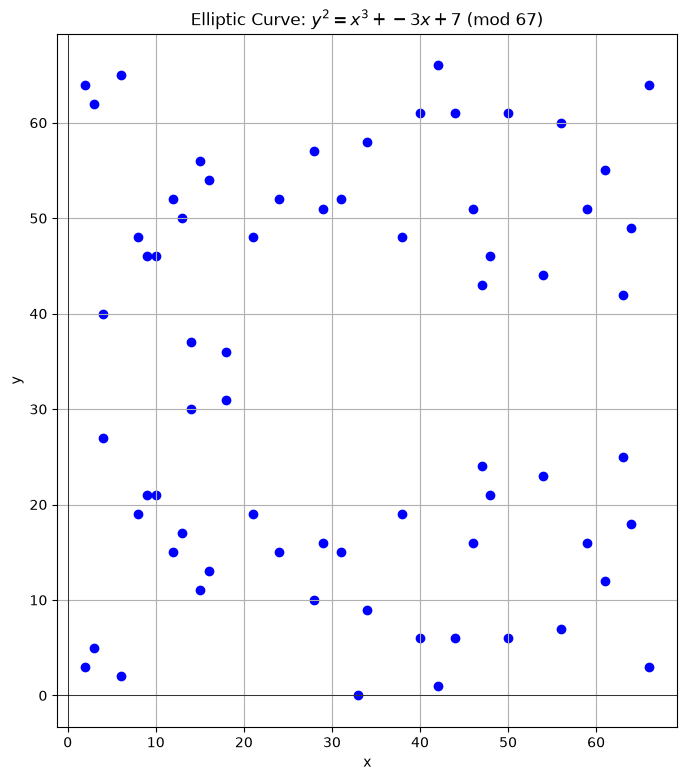

In [45]:
A = -3
B = 7
P = 67

plot_ec(A, B, P)

The image shows an elliptic curve with the equation

$$
y^2 = x^3 - 3x + 7 \pmod{67},  \quad \mathbb{F}_{67}.
$$

- The **green point** is the base point $G$, which serves as the starting point for scalar multiplication.  
- The **red point** is the public key $Q$, computed as
$$
Q = d \cdot G,
$$
where $d = 7$ is the private key.  

The process of multiplying the base point $G$ by the private key $d$ yields the public key $Q$, which is itself a point on the elliptic curve.


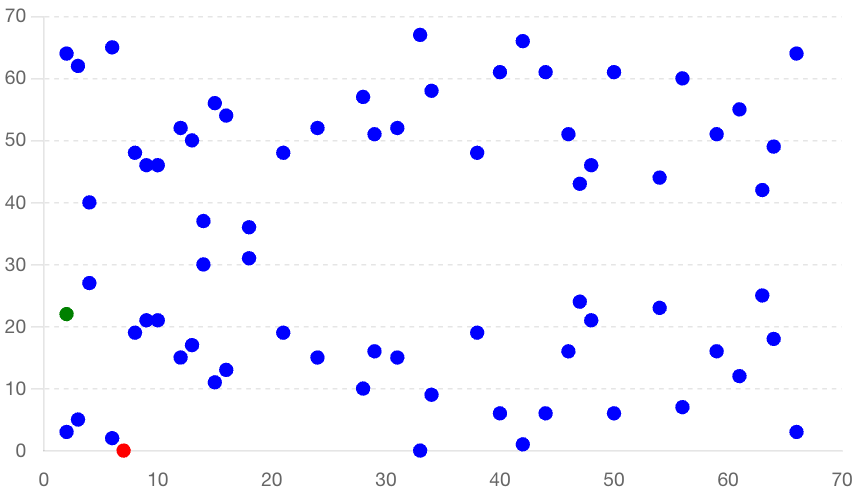

In [46]:
import hashlib

p = 114973          # field prime
A = -3
B = 69424
G = (11570, 42257)  # base point
n = 114467          # order of G (prime)

assert is_on_curve(G, A, B, p)
assert point_mul(n, G, A, p) is None   # n * G = O

def hash_to_int(m: str, n: int) -> int:
    e = int(hashlib.sha1(m.encode('utf-8')).hexdigest(), 16)
    # standard: keep the leftmost bit_length(n) bits of the digest
    return e >> max(0, e.bit_length() - n.bit_length())

def sign_message(m, d, G, p, n):
    e = hash_to_int(m, n)

    # k MUST be a fresh uniformly random value in [1, n-1] for every signature.
    # Reusing k (or a predictable k) leaks the private key d (Sony PS3, 2010).
    # Fixed here only for reproducibility.
    k = 84430

    x1, y1 = point_mul(k, G, A, p)
    r = x1 % n
    s = (inverse_mod(k, n) * (e + d * r)) % n
    assert r != 0 and s != 0, "pick another k"
    return (r, s)

def verify_signature(m, signature, Q, G, p, n):
    r, s = signature
    if not (1 <= r < n and 1 <= s < n):
        return False
    if Q is None or not is_on_curve(Q, A, B, p):
        return False

    e = hash_to_int(m, n)

    # w = s^(-1) mod n
    w = inverse_mod(s, n)

    # u1, u2
    u1 = (e * w) % n
    u2 = (r * w) % n

    # X = u1*G + u2*Q
    X1 = point_mul(u1, G, A, p)
    X2 = point_mul(u2, Q, A, p)
    X = point_add(X1, X2, A, p)
    if X is None:
        return False

    # r == x mod n
    return X[0] % n == r


d = 27927                       # private key, must be in [1, n-1]
Q = point_mul(d, G, A, p)       # public key
print("Public key Q:", Q)

message = "hello"
signature = sign_message(message, d, G, p, n)
print("Sign (r, s):", signature)

print("Valid with correct Q:     ", verify_signature(message, signature, Q, G, p, n))
print("Valid with tampered msg:  ", verify_signature("hellp", signature, Q, G, p, n))
print("Valid with other key:     ", verify_signature(message, signature, point_mul(d + 1, G, A, p), G, p, n))


Public key Q: (7227, 31566)
Sign (r, s): (31167, 3892)
Valid with correct Q:      True
Valid with tampered msg:   False
Valid with other key:      False


In [ ]:
d = 1345987138904708912374890132748901327089471389471089327441328764897
private_key_bytes = d.to_bytes(32, byteorder='big')
private_key_hex = private_key_bytes.hex()
private_key_hex

In [ ]:
!pip3 install ecdsa

In [47]:
from ecdsa import SigningKey, SECP256k1

message = "Hello, ECDSA!"

sk = SigningKey.generate(curve=SECP256k1)
print(f"Private key: {sk.to_string().hex()}")
vk = sk.verifying_key
print(f"Public key:  {vk.to_string().hex()}")

# we hash the message with our own SHA-256 and sign the digest directly
# (sk.sign(...) would hash the input again, with SHA-1 by default)
message_hash = sha256(message)
signature = sk.sign_digest(bytes.fromhex(message_hash))
print(f"Signature: {signature.hex()}")

is_valid = vk.verify_digest(signature, bytes.fromhex(message_hash))
print(f"Is valid: {is_valid}")


ModuleNotFoundError: No module named 'ecdsa'

### EIP712 (bonus)

https://eips.ethereum.org/EIPS/eip-712

## HW1

1. (3 point) Bitcoin wallet exploit

- Calculate the probability of generating an already used private key in the Bitcoin network, given that a total of 10^8 keys are in use. Give the formula and numerical results
- Verify your result experimentally on scaled-down versions of secp256k1. Here b denotes the bit length of the group order n, so n ≈ 2^b. The real secp256k1 has b = 256. For b = 20, 24, …, 40, find a prime p such that y² = x³ + 7 over F_p has a prime number of points n with b bits. Choose a population size N < n, measure how often a newly generated key matches one of the N existing ones, and compare with your formula. Plot log₂P against b and extrapolate to b = 256.

2. (3 points) Implement your own hash function in Python.

- Demonstrate the properties of a hash function on your input data:
- determinism
- computation speed
- avalanche effect
- uniformity
- chi sqaured
- collisions
- bit balances

Describe the advantages and disadvantages of your hash function based on benchmark results.  

3. (4 points) Based on the MerkleTree example from the seminar, implement:  

- a method to generate a Merkle Proof
- a method to verify whether a transaction is included in the merkle tree using the Merkle tree.

The full Merkle Proof for `tx2` consists of:

- The sibling hash at the first level: `h(tx1)`
- The hash from the second level: `h(tx3, tx4)`

```jsx

            Merkle Root
            /        \
      h(tx1, tx2)   h(tx3, tx4)
        /   \          /   \
    h(tx1) h(tx2)  h(tx3) h(tx4)

```